In [270]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [271]:
# Scikit-learn imports
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [272]:
# plotting
from matplotlib.colors import ListedColormap

In [273]:
def plot_decision_regions(X,y,classifier,test_idx=None,resolution=0.02):
    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1

    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),
                           np.arange(x2_min,x2_max,resolution))
    
    lab = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1,xx2,lab,alpha=0.3,cmap=cmap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())

    for idx,cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl,0],
                    y=X[y==cl,1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test samples
    if test_idx:
        print(X.shape, test_idx)
        X_test, y_test = X[test_idx,:], y[test_idx]
        print(X_test.shape)
        plt.scatter(X_test[:,0],
                    X_test[:,1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='test set')


In [274]:
def load_iris_data():
    # load iris data from sklearn
    iris = datasets.load_iris()
    X = iris.data[:, [2, 3]]
    y = iris.target
    return X,y



In [275]:
def preprocess_data(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y,shuffle=True,)
    sc = StandardScaler()
    sc.fit(X_train)
    X_train_std = sc.transform(X_train)
    X_test_std = sc.transform(X_test)
    return X_train_std,X_test_std,y_train,y_test

In [276]:
X,y = load_iris_data()
X_train_std,X_test_std,y_train,y_test = preprocess_data(X,y)
X_combined_std = np.vstack((X_train_std,X_test_std))
y_combined = np.hstack((y_train,y_test))

In [277]:
svm = SVC(kernel='linear',C=1.0,random_state=1)
svm.fit(X_train_std,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [278]:
X_combined_std.shape, y_combined.shape

((150, 2), (150,))

(150, 2) range(105, 140)
(35, 2)


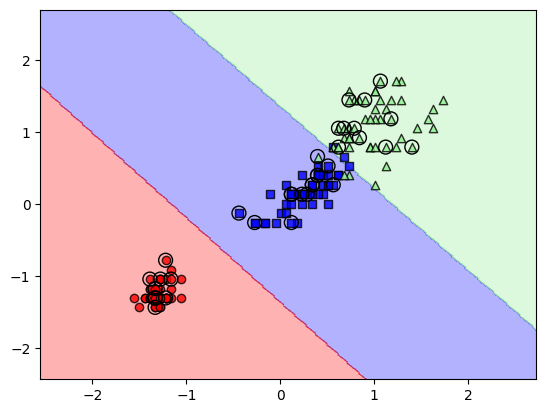

In [279]:
plot_decision_regions(X_combined_std,y_combined,classifier=svm, test_idx=range(105,140))

In [280]:
# Playing with XOR for non-linear kernel testing
np.random.seed(1)
X_xor = np.random.randn(200,2)
y_xor = np.logical_xor(X_xor[:,0]>0, X_xor[:,1]>0)

In [281]:
y_xor = np.where(y_xor,1,0)
y_xor

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1])

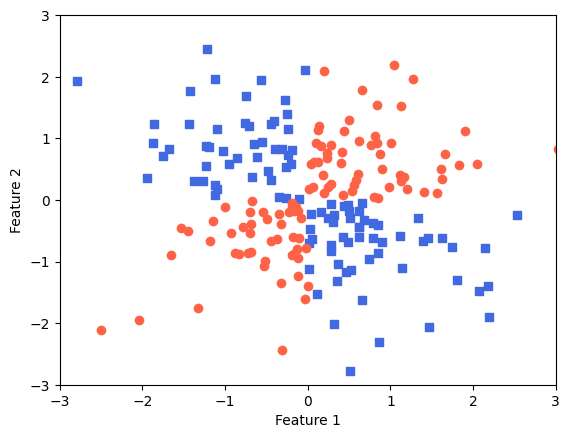

In [282]:
plt.scatter(X_xor[y_xor==1,0],X_xor[y_xor==1,1],
            c='royalblue',marker='s',label='Class 1')
plt.scatter(X_xor[y_xor==0,0],X_xor[y_xor==0,1],
            c='tomato',marker='o',label='Class 2')
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [283]:
svm = SVC(kernel='rbf',C=1.0,)
svm.fit(X_xor,y_xor)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


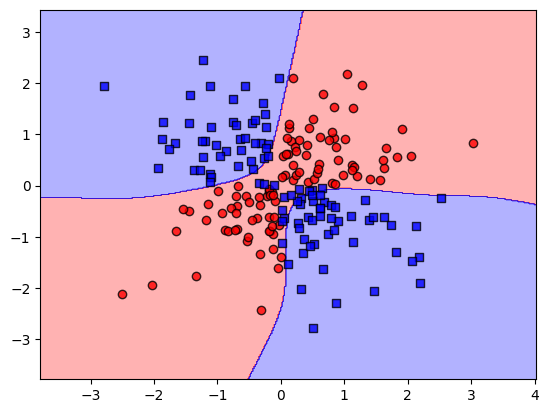

In [284]:
plot_decision_regions(X_xor,y_xor,classifier=svm)